Dans ce projet, nous avons choisi d’utiliser deux jeux de données afin d’évaluer la robustesse et la généralisabilité des modèles étudiés, notamment les Reinforcement Learning Trees (RLT). L’utilisation d’un seul dataset ne permettrait pas de vérifier si les performances observées sont propres à un contexte particulier ou si elles se maintiennent dans des situations variées. Nous avons ainsi retenu le dataset Breast Cancer Wisconsin (Diagnostic), qui correspond à un problème de classification médicale avec 30 variables numériques, et le dataset Wine Quality, qui relève d’un problème de régression dans le domaine agroalimentaire avec une structure de données plus simple et un nombre de variables réduit. Ces deux datasets se complètent parfaitement : ils diffèrent par leur nature (classification vs régression), leur domaine d’application (santé vs industrie), leur dimensionnalité et leur taille. Ce contraste permet d’examiner le comportement de RLT et des modèles comparatifs dans des environnements hétérogènes, renforçant ainsi la pertinence et la portée des conclusions obtenues.

## Phase 1 : Business Understanding


### Business Objectif 1 : Réduire la charge de travail et le risque d’erreurs humaines en analyse médicale
L’analyse des biopsies mammaires représente une tâche lourde et exigeante pour les professionnels de santé. Elle demande du temps, de la précision et peut parfois conduire à des variations dans les évaluations d’un expert à l’autre. En mettant en place un modèle automatisé capable de fournir une première estimation du diagnostic, il devient possible d’alléger ce travail, d’apporter un soutien fiable aux médecins et de limiter les risques d’erreurs. L’objectif est donc de rendre le diagnostic plus rapide, plus cohérent et moins dépendant exclusivement de l’œil humain.

### Business Objectif 2 : Optimiser les ressources médicales en priorisant les cas à risque
Dans un contexte hospitalier où les ressources sont souvent limitées, il est crucial de pouvoir identifier rapidement les patientes qui nécessitent une attention immédiate. Un modèle prédictif capable d’estimer la probabilité qu’une tumeur soit maligne permettrait de mettre en place un tri efficace des dossiers, en faisant passer en priorité les cas les plus sensibles. Cela aiderait les équipes médicales à mieux organiser leur travail, à réduire les délais pour les situations urgentes et à concentrer leur temps sur les patientes qui en ont le plus besoin.

### Data Science Objective 1 :
Développer un modèle de classification capable de prédire automatiquement si une tumeur est bénigne ou maligne, afin d’apporter un soutien fiable et rapide au diagnostic médical.

### Data Science Objective 2 :
Identifier les variables les plus influentes pour comprendre ce qui distingue un cas à risque élevé et permettre une meilleure priorisation des patientes.

## ------------------------------------------------------------

### Business Objectif 3(Wine Quality): Améliorer la cohérence et la rapidité de l’évaluation de la qualité des vins
L’évaluation de la qualité des vins repose encore largement sur l’avis de dégustateurs humains, ce qui peut entraîner des résultats variables d’un expert à l’autre et rendre le processus long et coûteux. L’objectif ici est de disposer d’un outil capable d’estimer automatiquement la qualité d’un vin à partir de mesures physico-chimiques simples. Un tel système permettrait d’obtenir une analyse plus rapide et plus uniforme, tout en réduisant la dépendance aux jugements subjectifs. Cela faciliterait le travail des équipes de contrôle qualité et améliorerait la cohérence des évaluations.

### Business Objectif 4 (Wine Quality) : Aider les producteurs à prendre les bonnes décisions tout au long de la production 
La qualité finale d’un vin dépend de nombreux choix effectués pendant la production : durée de fermentation, assemblages, traitements, etc. Pouvoir prédire la qualité future d’un vin grâce à un modèle automatique donnerait aux producteurs une vision plus claire dès les premières étapes du processus. Cela leur permettrait d’adapter leurs décisions techniques au bon moment et de concentrer leurs efforts sur les cuvées les plus prometteuses. L’objectif est donc d’améliorer l’efficacité globale de la production en évitant du gaspillage et en valorisant plus rapidement les vins de meilleure qualité.


### Data Science Objective 3 (Wine Quality) : Construire un modèle capable d’estimer la qualité d’un vin : 
Développer un modèle de régression qui puisse prédire la note de qualité d’un vin à partir de ses caractéristiques physico-chimiques. L’idée est de reproduire au mieux l’avis d’un expert, mais de manière plus rapide et plus cohérente. Ce modèle doit permettre d’évaluer automatiquement un vin sans passer par une dégustation systématique, ce qui constitue un gain de temps important pour les producteurs et les équipes de contrôle qualité.

### Data Science Objective 4 (Wine Quality) : Comprendre ce qui influence réellement la qualité d’un vin : 
Identifier les facteurs physico-chimiques qui influencent le plus la qualité d’un vin afin d’aider les producteurs à mieux comprendre et optimiser leur processus de production.

## Phase 2 : Data Understanding

In [3]:
import pandas as pd
bc = pd.read_csv("BreastCanDT.csv")

In [5]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
bc.shape

(569, 33)

In [11]:
bc.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [13]:
bc.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [15]:
bc['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [17]:
bc['diagnosis'].value_counts(normalize=True) * 100


diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

## distribution de la cible (diagnosis)

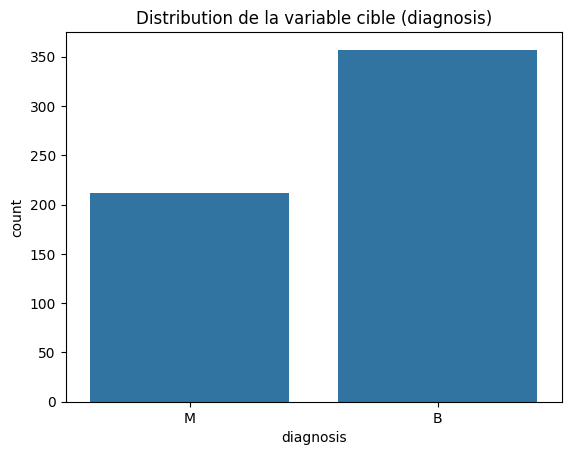

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=bc, x='diagnosis')
plt.title("Distribution de la variable cible (diagnosis)")
plt.show()

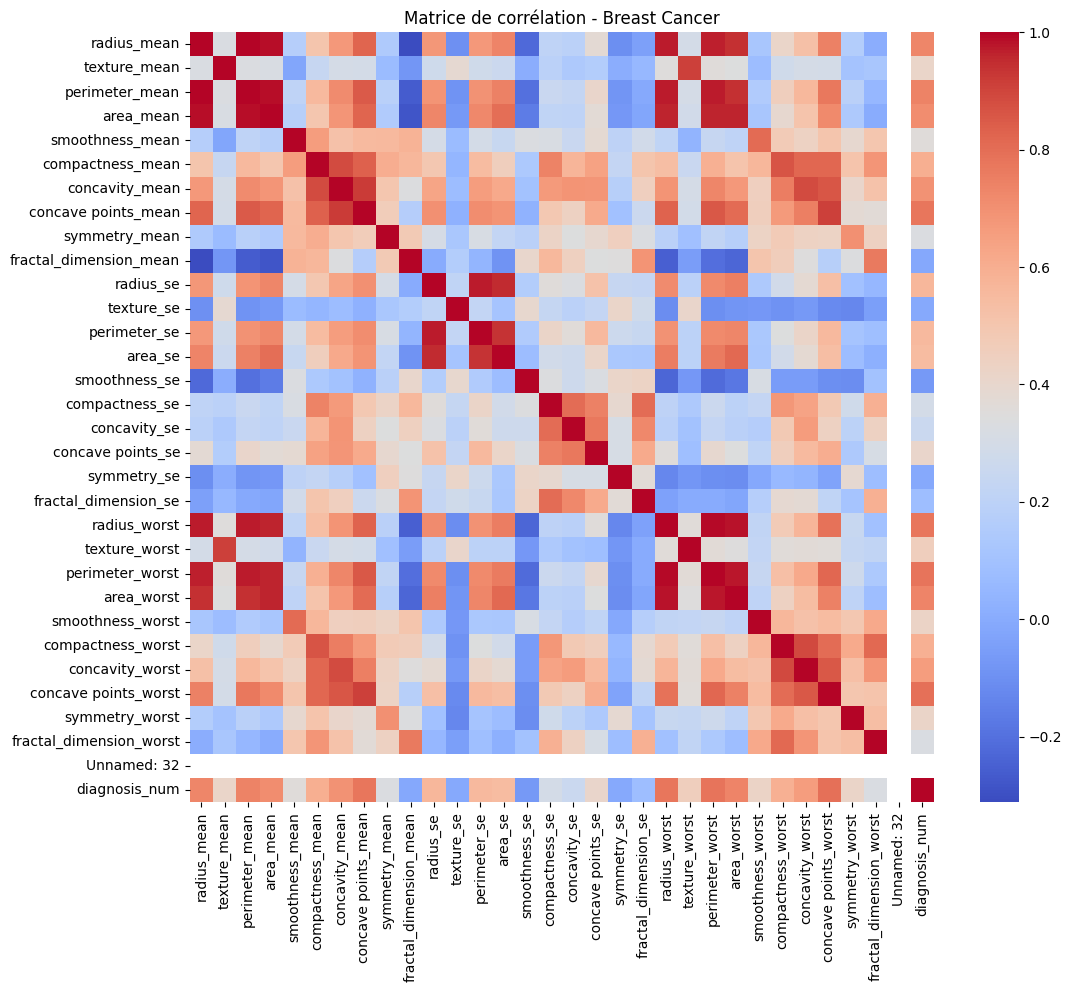

In [25]:
bc['diagnosis_num'] = bc['diagnosis'].map({'M': 1, 'B': 0})

bc_numeric = bc.drop(columns=['id', 'diagnosis'])

plt.figure(figsize=(12,10))
sns.heatmap(bc_numeric.corr(), cmap='coolwarm')
plt.title("Matrice de corrélation - Breast Cancer")
plt.show()


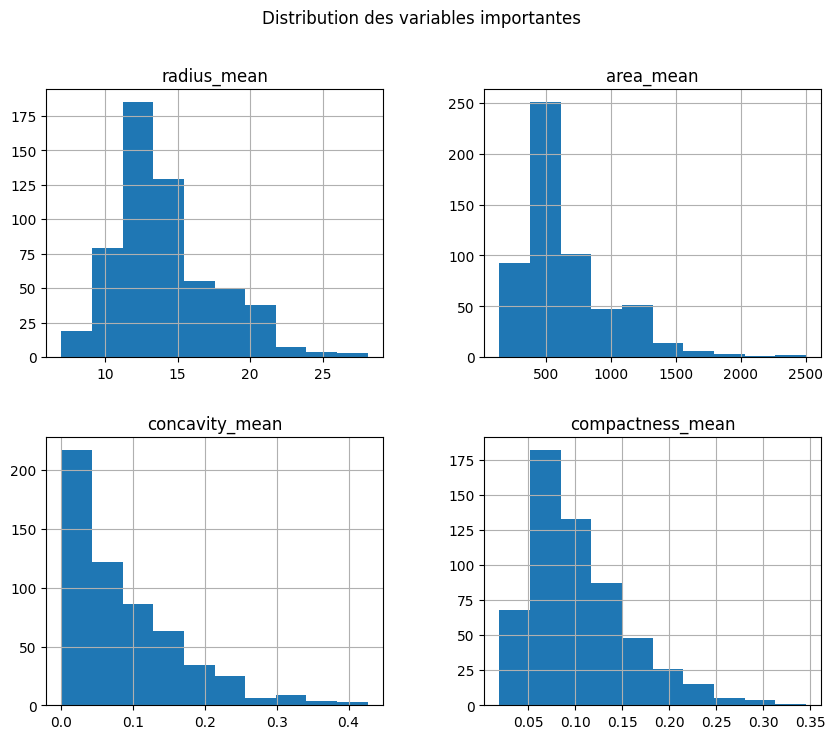

In [27]:
bc[['radius_mean','area_mean','concavity_mean','compactness_mean']].hist(figsize=(10,8))
plt.suptitle("Distribution des variables importantes")
plt.show()


In [29]:
bc.groupby('diagnosis')[['radius_mean','area_mean','concavity_mean','compactness_mean']].mean()


,radius_mean,area_mean,concavity_mean,compactness_mean
diagnosis,,,,
B,12.146524,462.790196,0.046058,0.080085
M,17.462830,978.376415,0.160775,0.145188


## Détection des outliers

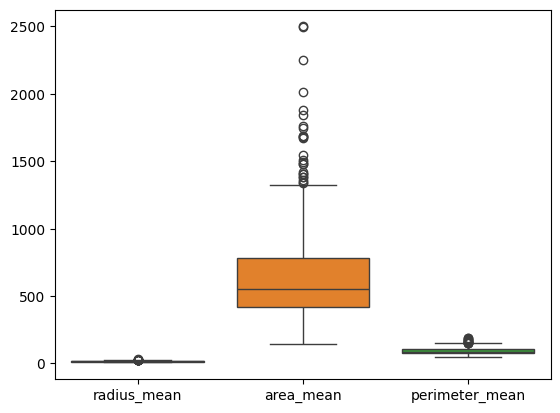

In [32]:
sns.boxplot(data=bc[['radius_mean','area_mean','perimeter_mean']])
plt.show()


## -----------------------Wine Quality----------------------

In [38]:
wine = pd.read_csv("WineDT.csv")

In [40]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [42]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [44]:
wine.shape

(1143, 13)

In [46]:
wine.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [48]:
wine.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000
